**ASSIGNMENT 5: Sentiment Analysis Using Recurrent Neural Networks (RNN) with IMDB Dataset**

**Name:** EDUARDO WILLIAMS

**Student code:** C0896405

**Date:** August 9, 2024

**Objective:**

The objective of this assignment is to implement a Recurrent Neural Network (RNN) using TensorFlow to perform sentiment analysis on the IMDB movie review dataset. You will train the RNN to classify movie reviews as positive or negative and analyze the model's performance.

**Installing and importing necessary libraries**

In [3]:
%pip install tensorflow-datasets

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/5.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.1 MB 325.1 kB/s eta 0:00:16
   ---------------------------------------- 0.0/5.1 MB 325.1 kB/s eta 0:00:16
   ---------------------------------------- 0.0/5.1 MB 178.6 kB/s eta 0:00:29
   ---------------------------------------- 0.1/5.1 MB 252.2 kB/s eta 0:00:20
    --------------------------------------- 0.1/5.1 MB 364.4 kB/s eta 0:00:14
    --------------------------------------- 0.1/5.1 MB 364.4 kB/s eta 0:00:14
    --------------------------------------- 0.1/5.1 MB 364.4 kB/s eta 0:00:14
    ------


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [245]:
%pip install scikeras

  Using cached scikeras-0.13.0-py3-none-any.whl.metadata (3.1 kB)
Using cached scikeras-0.13.0-py3-none-any.whl (26 kB)
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB 330.3 kB/s eta 0:00:34
   ---------------------------------------- 0.0/11.0 MB 393.8 kB/s eta 0:00:28
   ---------------------------------------- 0.0/11.0 MB 393.8 kB/s eta 0:00:28
   ---------------------------------------- 0.1/11.0 MB 299.4 kB/s eta 0:00:37
   ---------------------------------------- 0.1/11.0 MB 302.7 kB/s eta 0:00:37
   ---------------------------------------- 0.1/11.0 MB 350.1 kB/s eta 0:00:32
   ---------------------------------------- 0.1/11.0 MB 343.4 kB/s eta 0:00:32
    --------------------------------------- 0.1/11.0 MB 355.0 kB/s eta 0:00:31
    --------------------------------------- 0.2/11.0 MB 389.2 kB/s eta 0:00:28
    -------------------------

  You can safely remove it manually.

[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [247]:
%pip install sklearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [249]:
%pip install _get_container_adapter

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '_get_container_adapter'

[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
# Importing necessary libraries
import numpy as np
from matplotlib import pyplot as plt

# Importing layers and base network
import tensorflow          as tf
import tensorflow_datasets as tfds

from sklearn.model_selection                 import GridSearchCV
from scikeras.wrappers                       import KerasClassifier
from tensorflow.keras.layers                 import Input, Dense, Embedding, Bidirectional, LSTM, Dropout, Flatten
from tensorflow.keras.models                 import Sequential, Model
from tensorflow.keras.callbacks              import EarlyStopping
from tensorflow.keras.optimizers             import Adam
from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

**DATASET PREPARATION**

Loading the IMDB dataset provided by TensorFlow

In [22]:
# loading the dataset
imdb = tfds.load('imdb_reviews', as_supervised=True)

In [23]:
print (len(imdb['train']))
print (len(imdb['test']))

25000
25000


In [24]:
# train_data, test_data = imdb['train'], imdb['test']

train_msg = []
train_lbl = []
test_msg  = []
test_lbl  = []

for review, label in imdb['train']:
    train_msg.append(str(review.numpy()))
    train_lbl.append(str(label.numpy()))
    
for review, label in imdb['test']:
    test_msg.append(str(review.numpy()))
    test_lbl.append(str(label.numpy()))

In [25]:
train_lbl = np.array(train_lbl).astype(np.float16)
test_lbl  = np.array(test_lbl).astype(np.float16)

**Tokenizing the text and converting tokens to numerical format**

In [28]:
num_epochs = 20
batches_per_epoch = len(train_msg)
lr_decay = (1. / 0.75 - 1) / batches_per_epoch

vocab_size = 10000   # The maximum number of words to keep, based on word frequency 
embed_size = 128     # Dimension of the dense embedding
max_len    = 200     # Length of input sequences, when it is constant

In [29]:
tokenizer = Tokenizer(num_words = vocab_size, 
                      filters   = '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
                      lower     = True,
                      split     = " ",
                      oov_token = "<OOV>")

tokenizer.fit_on_texts(train_msg)

In [30]:
tokenizer.word_index

{'<OOV>': 1,
 'the': 2,
 'and': 3,
 'a': 4,
 'of': 5,
 'to': 6,
 'is': 7,
 'br': 8,
 'in': 9,
 'it': 10,
 'i': 11,
 'this': 12,
 'that': 13,
 'was': 14,
 'as': 15,
 'for': 16,
 'with': 17,
 'movie': 18,
 'but': 19,
 'film': 20,
 "'s": 21,
 'on': 22,
 'you': 23,
 'not': 24,
 'are': 25,
 'his': 26,
 'he': 27,
 'have': 28,
 'be': 29,
 'one': 30,
 'all': 31,
 'at': 32,
 'by': 33,
 'they': 34,
 'an': 35,
 'who': 36,
 'so': 37,
 'from': 38,
 'like': 39,
 'her': 40,
 "'t": 41,
 'or': 42,
 'just': 43,
 'there': 44,
 'about': 45,
 'out': 46,
 "'": 47,
 'has': 48,
 'if': 49,
 'some': 50,
 'what': 51,
 'good': 52,
 'more': 53,
 'very': 54,
 'when': 55,
 'she': 56,
 'up': 57,
 'can': 58,
 'b': 59,
 'time': 60,
 'no': 61,
 'even': 62,
 'my': 63,
 'would': 64,
 'which': 65,
 'story': 66,
 'only': 67,
 'really': 68,
 'see': 69,
 'their': 70,
 'had': 71,
 'were': 72,
 'me': 73,
 'well': 74,
 'we': 75,
 'than': 76,
 'much': 77,
 'been': 78,
 'get': 79,
 'bad': 80,
 'will': 81,
 'people': 82,
 'do': 83,

**Padding sequences to ensure uniform input length**

In [31]:
# tokenized and padding
train_seq = tokenizer.texts_to_sequences(train_msg)
test_seq  = tokenizer.texts_to_sequences(test_msg)

train_pad = pad_sequences(train_seq, maxlen = max_len, truncating = 'post')
test_pad  = pad_sequences(test_seq,  maxlen = max_len, truncating = 'post')

print (train_msg[0])
print (train_pad[0])

b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
   

**BUILDING THE RNN MODEL**

**Implement an RNN model using TensorFlow and Keras**

In [32]:
# Define the model architecture

# Input layer
# Input for variable-length sequences of integers
inputs = Input(shape=(None,), dtype="int32")

# Embedding layer
# Embed each integer 
x = Embedding(input_dim    = vocab_size, 
              output_dim   = embed_size,
              input_length = max_len)(inputs)

# RNN layer (use LSTM or GRU for better performance)
# Add 2 bidirectional LSTMs
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Bidirectional(LSTM(64))(x)

# Output layer
# Add a classifier
outputs = Dense(1, activation="sigmoid")(x)

# tf.keras.Model
rnn_model = Model(inputs, outputs)

c:\Users\Eduardo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


**Compile the model with an appropriate loss function and optimizer**

In [33]:
opt_adam = Adam(learning_rate = 0.0001, weight_decay = lr_decay)

In [34]:
# Compile the model
rnn_model.compile(loss      = 'binary_crossentropy',
                  optimizer = opt_adam,
                  metrics   = ['accuracy'])

**TRAINING THE MODEL**

**Use early stopping with restore_best_weights enabled**

In [35]:
early_stopping = EarlyStopping(monitor              = 'val_loss',
                               mode                 = 'min',
                               patience             = 5,
                               min_delta            = 0.01,
                               verbose              = 1,
                               restore_best_weights = True)

**Train the model on the training set and validate it on the validation set**

In [36]:
hist = rnn_model.fit(train_pad,
                     train_lbl,
                     validation_split = 0.3,
                     epochs           = num_epochs,
                     batch_size       = 32,
                     verbose          = 1,
                     callbacks        = [early_stopping])

Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 90s 158ms/step - accuracy: 0.5781 - loss: 0.6532 - val_accuracy: 0.8336 - val_loss: 0.3791
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 84s 153ms/step - accuracy: 0.8841 - loss: 0.2996 - val_accuracy: 0.8493 - val_loss: 0.3709
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 86s 157ms/step - accuracy: 0.9246 - loss: 0.2166 - val_accuracy: 0.8545 - val_loss: 0.3519
Epoch 4/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 131s 239ms/step - accuracy: 0.9524 - loss: 0.1520 - val_accuracy: 0.8431 - val_loss: 0.4127
Epoch 5/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 137s 250ms/step - accuracy: 0.9600 - loss: 0.1254 - val_accuracy: 0.8527 - val_loss: 0.4245
Epoch 6/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 112s 205ms/step - accuracy: 0.9752 - loss: 0.0921 - val_accuracy: 0.8503 - val_loss: 0.4182
Epoch 7/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 109s 199ms/step - accuracy: 0.9741 - loss: 0.0900 - val_accuracy: 0.8449 - val_loss: 0.4722
Epoch 8/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 114s 208ms/step - accuracy: 0.9846 - lo

**EVALUATING THE MODEL**

**Plot the training and validation loss and accuracy over epochs to visualize the training process**

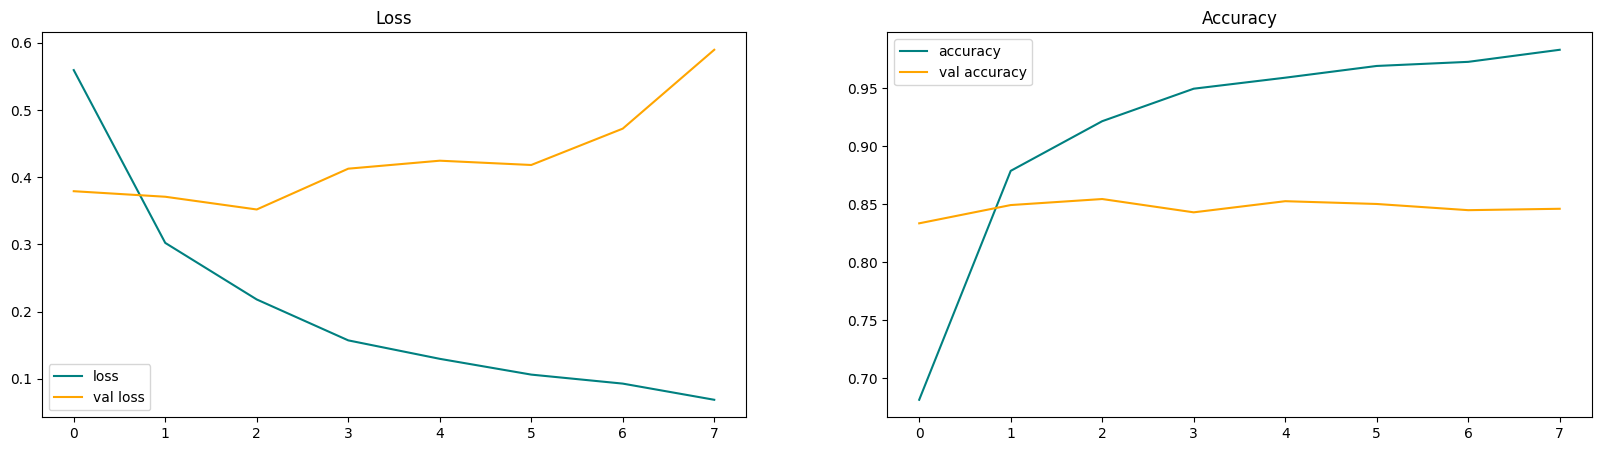

In [37]:
fig, ax = plt.subplots(ncols=2, figsize=(20,5))

ax[0].plot(hist.history['loss'], color='teal', label='loss')
ax[0].plot(hist.history['val_loss'], color='orange', label='val loss')
ax[0].title.set_text('Loss')
ax[0].legend()

ax[1].plot(hist.history['accuracy'], color='teal', label='accuracy')
ax[1].plot(hist.history['val_accuracy'], color='orange', label='val accuracy')
ax[1].title.set_text('Accuracy')
ax[1].legend()

plt.show()

**Evaluate the model’s performance using appropriate metrics (e.g., accuracy, loss)**

In [38]:
# evaluating the model on test dataset
test_loss, test_acc = rnn_model.evaluate(test_pad, test_lbl, verbose = 2)

print (f'Accuracy ==> {test_acc:.2f}')
print (f'Loss     ==> {test_loss:.2f}')

782/782 - 38s - 49ms/step - accuracy: 0.8419 - loss: 0.3759
Accuracy ==> 0.84
Loss     ==> 0.38


**HYPERPARAMETER TUNING**

In [18]:
def create_model(neurons, dropout_rate):
    # Define the model architecture
    
    # Input layer
    # Input for variable-length sequences of integers
    inputs = Input(shape=(None,), dtype="int32")
    
    # Embedding layer
    # Embed each integer 
    x = Embedding(input_dim  = vocab_size, 
                  output_dim = embed_size)(inputs)
     
    # RNN layer (use LSTM or GRU for better performance)
    # Add 2 bidirectional LSTMs
    x = Bidirectional(LSTM(neurons, dropout = dropout_rate, return_sequences = True))(x)
    x = Bidirectional(LSTM(neurons, dropout = dropout_rate))(x)
    
    #x = Dropout(dropout_rate)(x)
    
    # Output layer
    # Add a classifier
    outputs = Dense(1, activation = "sigmoid")(x)

    # tf.keras.Model
    model = Model(inputs, outputs)
    
    # Compile the model
    # model.compile(loss      = 'binary_crossentropy',
    #               optimizer = 'adam',
    #               metrics   = ['accuracy'])
        
    return model

In [19]:
# creating KerasClassifier model
k_model = KerasClassifier(model      = create_model,
                          loss       = "binary_crossentropy",
                          optimizer  = "adam",
                          epochs     = num_epochs,
                          batch_size = 32, 
                          verbose    = 1,
                          metrics    = ['accuracy'])

# define the grid search parameters
learn_rate   = [0.000001, 0.00001]
dropout_rate = [0.3, 0.5]
neurons      = [256, 512]

param_grid = dict(optimizer__learning_rate = learn_rate,
                  model__dropout_rate      = dropout_rate,
                  model__neurons           = neurons)

grid_cv = GridSearchCV(estimator  = k_model,
                       param_grid = param_grid, 
                       n_jobs     = 1,              # the process will use all cores on your machine
                       cv         = 3)

# defining early_stopping
stopper = EarlyStopping(monitor              = 'val_accuracy',
                        mode                 = 'max',
                        patience             = 5,
                        min_delta            = 0.01,
                        verbose              = 1,
                        restore_best_weights = True)

fit_params = dict(callbacks=[stopper])
 
grid_result = grid_cv.fit(train_pad, train_lbl, **fit_params)

Epoch 1/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 829s 2s/step - accuracy: 0.4914 - loss: 0.6932
Epoch 2/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 792s 2s/step - accuracy: 0.4989 - loss: 0.6932
Epoch 3/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 847s 2s/step - accuracy: 0.5104 - loss: 0.6931
Epoch 4/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 701s 1s/step - accuracy: 0.5073 - loss: 0.6931
Epoch 5/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 724s 1s/step - accuracy: 0.5140 - loss: 0.6929
Epoch 6/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 699s 1s/step - accuracy: 0.5242 - loss: 0.6929
Epoch 7/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 829s 2s/step - accuracy: 0.5251 - loss: 0.6928
Epoch 8/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 906s 2s/step - accuracy: 0.5329 - loss: 0.6928
Epoch 9/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 1021s 2s/step - accuracy: 0.5455 - loss: 0.6926
Epoch 10/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 1011s 2s/step - accuracy: 0.5431 - loss: 0.6925
Epoch 11/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 928s 2s/step - accuracy: 0.5469 - loss: 0.6925
Epoch 12/20
521/521 ━━━━━━━━━━━━━━━━━━━

KeyboardInterrupt: 

In [ ]:
# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

means  = grid_result.cv_results_['mean_test_score']
stds   = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']

for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))


**COMPARATIVE ANALYSIS**

**Implement another neural network architecture (e.g., a simple feedforward neural network) for the same task**

In [53]:
# building an ANN model
model_ffn = Sequential()
model_ffn.add(Embedding(input_dim  = vocab_size, output_dim = embed_size))
model_ffn.add(Flatten())
model_ffn.add(Dense(128, activation = 'relu'))
model_ffn.add(Dropout(0.3))
model_ffn.add(Dense(64, activation = 'relu'))
model_ffn.add(Dropout(0.3))
model_ffn.add(Dense(1, activation='sigmoid'))

In [54]:
# compiling the model
model_ffn.compile(loss      = 'binary_crossentropy',
                  optimizer = 'adam',
                  metrics   = ['accuracy'])

In [55]:
# model training
hist_ffn = model_ffn.fit(train_pad,
                         train_lbl,
                         epochs           = num_epochs,
                         batch_size       = 32,
                         validation_split = 0.3,
                         verbose          = 1,
                         callbacks        = [early_stopping])

Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.6586 - loss: 0.5793 - val_accuracy: 0.8485 - val_loss: 0.3494
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.9611 - loss: 0.1145 - val_accuracy: 0.8155 - val_loss: 0.4997
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.9958 - loss: 0.0152 - val_accuracy: 0.7671 - val_loss: 1.1413
Epoch 4/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.9952 - loss: 0.0143 - val_accuracy: 0.8184 - val_loss: 0.9524
Epoch 5/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.9944 - loss: 0.0158 - val_accuracy: 0.8105 - val_loss: 0.8646
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


**Compare the performance of the RNN with this alternative model**

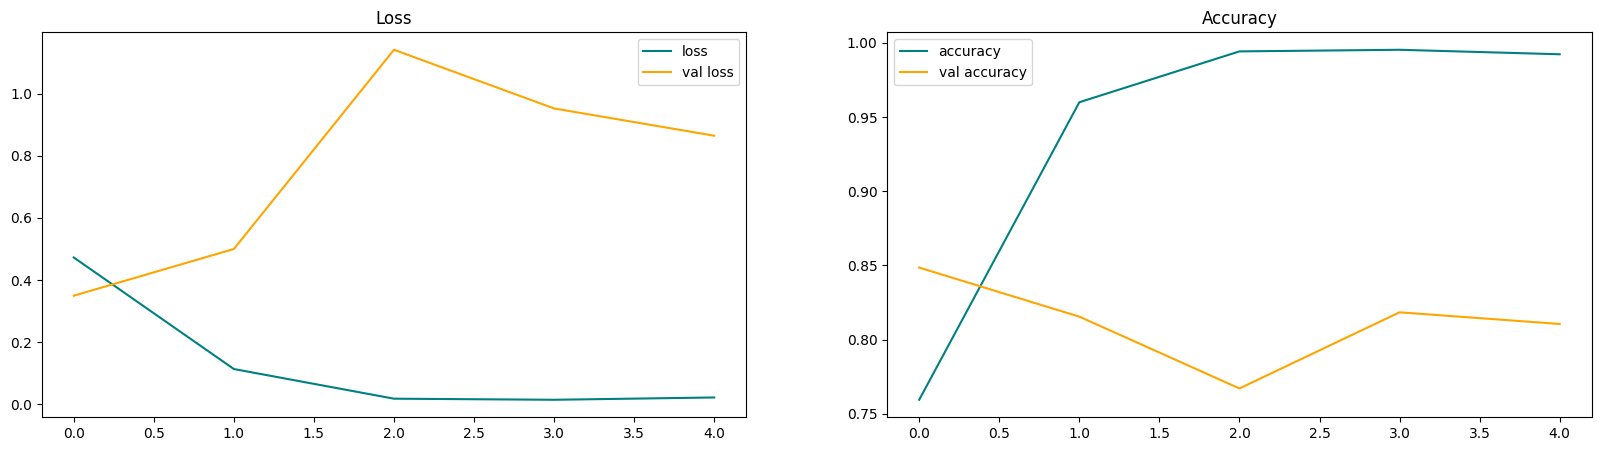

In [57]:
# plotting ANN results
fig, ax = plt.subplots(ncols=2, figsize=(20,5))

ax[0].plot(hist_ffn.history['loss'], color='teal', label='loss')
ax[0].plot(hist_ffn.history['val_loss'], color='orange', label='val loss')
ax[0].title.set_text('Loss')
ax[0].legend()

ax[1].plot(hist_ffn.history['accuracy'], color='teal', label='accuracy')
ax[1].plot(hist_ffn.history['val_accuracy'], color='orange', label='val accuracy')
ax[1].title.set_text('Accuracy')
ax[1].legend()

plt.show()

In [58]:
# evaluating the model on test dataset
test_loss_ffn, test_acc_ffn = model_ffn.evaluate(test_pad, test_lbl)

print (f'Accuracy ==> {test_acc_ffn:.2f}')
print (f'Loss     ==> {test_loss_ffn:.2f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8415 - loss: 0.3618
Accuracy ==> 0.84
Loss     ==> 0.36
